In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")
import plotly.express as px

df = pd.read_csv(r"C:\Users\Dell\Downloads\GlobalWeatherRepository.csv")
pd.set_option('display.max_columns', None)
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [2]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124331 entries, 0 to 124330
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       124331 non-null  object 
 1   location_name                 124331 non-null  object 
 2   latitude                      124331 non-null  float64
 3   longitude                     124331 non-null  float64
 4   timezone                      124331 non-null  object 
 5   last_updated_epoch            124331 non-null  int64  
 6   last_updated                  124331 non-null  object 
 7   temperature_celsius           124331 non-null  float64
 8   temperature_fahrenheit        124331 non-null  float64
 9   condition_text                124331 non-null  object 
 10  wind_mph                      124331 non-null  float64
 11  wind_kph                      124331 non-null  float64
 12  wind_degree                   124331 non-nul

In [15]:
important_cols = [
    'country',
    'last_updated',
    'temperature_celsius',
    'humidity',
    'wind_kph',
    'pressure_mb',
    'air_quality_PM2.5',
    'air_quality_PM10'
]

In [16]:
df[important_cols].isnull().sum()

country                0
last_updated           0
temperature_celsius    0
humidity               0
wind_kph               0
pressure_mb            0
air_quality_PM2.5      0
air_quality_PM10       0
dtype: int64

In [17]:
#Converted Date Properly
df['last_updated'] = pd.to_datetime(df['last_updated'])
df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day

In [18]:
#Stats Summary
df[important_cols].describe()

,last_updated,temperature_celsius,humidity,wind_kph,pressure_mb,air_quality_PM2.5,air_quality_PM10
count,124331,124331.000000,124331.000000,124331.000000,124331.000000,124331.000000,124331.000000
mean,2025-04-01 15:41:18.175998208,21.624684,66.121265,12.992079,1014.058264,24.612718,49.238644
min,2024-05-16 01:45:00,-29.800000,2.000000,3.600000,947.000000,0.168000,-1848.150000
25%,2024-10-24 07:15:00,16.300000,50.000000,6.500000,1010.000000,7.100000,10.050000
50%,2025-04-01 22:30:00,24.100000,71.000000,11.200000,1014.000000,14.250000,20.350000
75%,2025-09-08 10:15:00,28.100000,85.000000,17.600000,1018.000000,28.120000,42.180000
max,2026-02-15 19:45:00,49.200000,100.000000,2963.200000,3006.000000,1614.100000,6037.290000
std,NaN,9.573227,24.020760,11.869220,10.625605,37.882984,152.008615


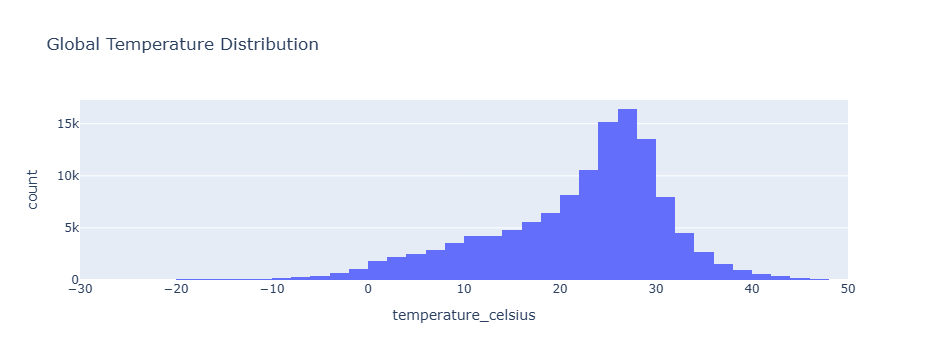

In [19]:
import plotly.express as px
#Temperature Distribution
px.histogram(df,
             x='temperature_celsius',
             nbins=60,
             title='Global Temperature Distribution')

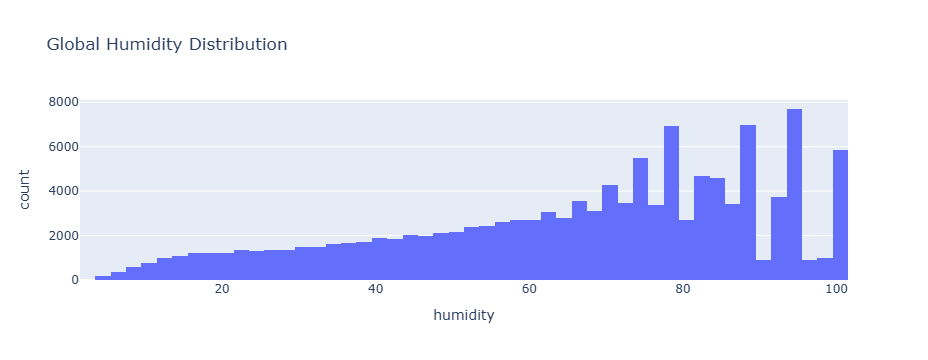

In [20]:
#Humidity Distribution
px.histogram(df,
             x='humidity',
             nbins=50,
             title='Global Humidity Distribution')

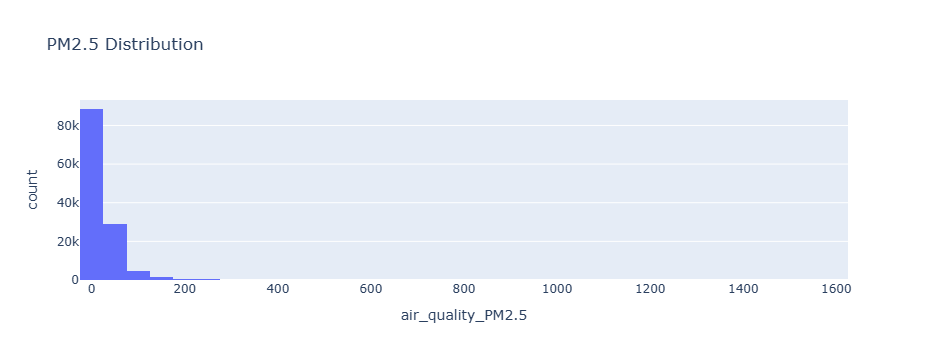

In [21]:
#Air Quality Distribution
px.histogram(df,
             x='air_quality_PM2.5',
             nbins=60,
             title='PM2.5 Distribution')

In [22]:
#CORR ANALYSIS
corr_matrix = df[
    ['temperature_celsius','humidity','wind_kph',
     'pressure_mb','air_quality_PM2.5']
].corr()

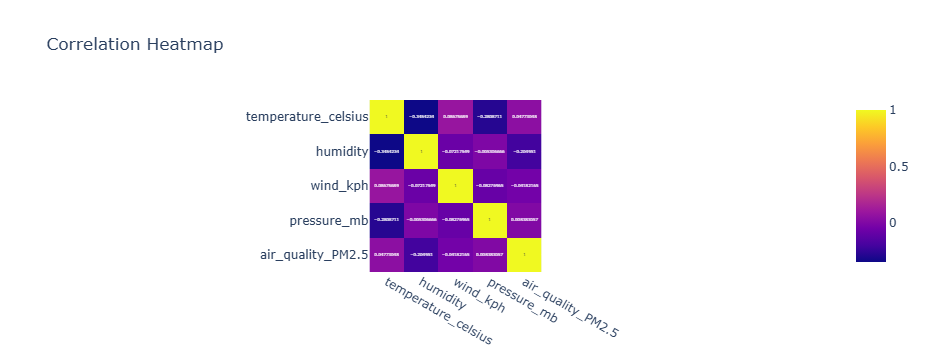

In [23]:
px.imshow(corr_matrix,
          text_auto=True,
          title='Correlation Heatmap')

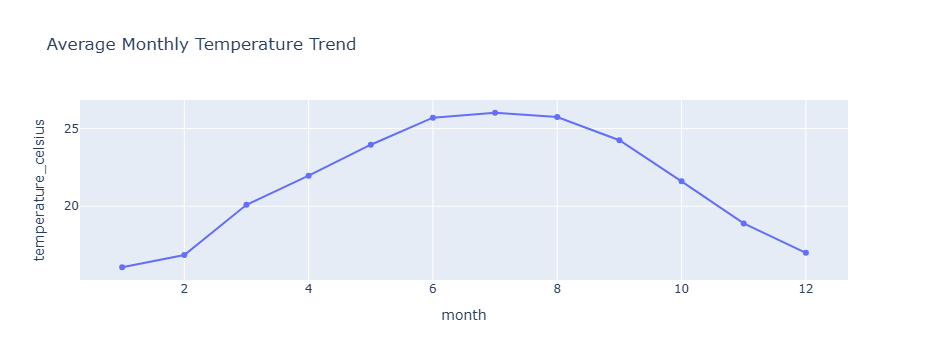

In [24]:
#SEASONAL PATTERN ANALYSIS
#Monthly Temperature Trend
monthly_avg = df.groupby('month')['temperature_celsius'].mean().reset_index()

px.line(monthly_avg,
        x='month',
        y='temperature_celsius',
        title='Average Monthly Temperature Trend', 
        markers = True)

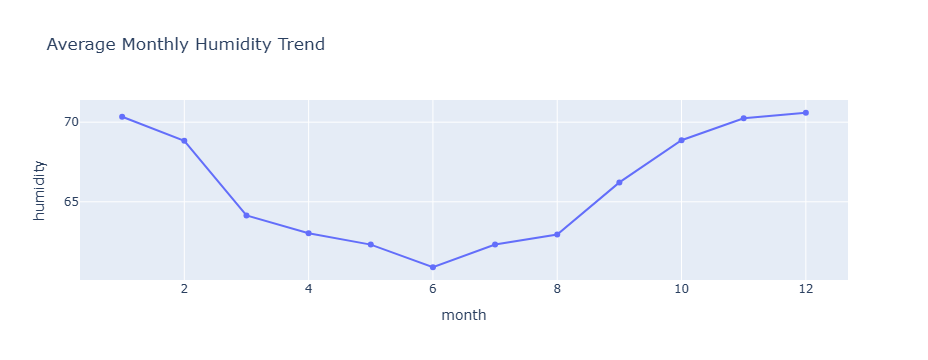

In [25]:
#Monthly Humidity
monthly_humidity = df.groupby('month')['humidity'].mean().reset_index()

px.line(monthly_humidity,
        x='month',
        y='humidity',
        title='Average Monthly Humidity Trend',
        markers = True)

In [26]:
#REGIONAL COMPARISON
country_temp = df.groupby('country')['temperature_celsius'].mean().reset_index()

In [27]:
#Top 10 hottest countries
country_temp.sort_values(by='temperature_celsius', ascending=False).head(10)

,country,temperature_celsius
158,Saudi Arabien,45.000000
114,Marrocos,40.300000
189,Turkménistan,37.800000
208,Турция,34.000000
147,Qatar,32.781661
194,United Arab Emirates,32.778247
48,Djibouti,31.777080
94,Kuwait,31.747261
136,Oman,31.591080
157,Saudi Arabia,31.438619


In [28]:
#Top 10 coldest countries
country_temp.sort_values(by='temperature_celsius').head(10)

,country,temperature_celsius
122,Mongolia,4.045055
31,Canada,5.438836
76,Iceland,5.961755
135,Norway,8.432810
196,United States of America,8.773734
89,Kazakhstan,8.806740
60,Finland,9.307981
149,Russia,9.387221
56,Estonia,9.631034
3,Andorra,9.786698


In [29]:
#Country-wise Air Quality
country_aqi = df.groupby('country')['air_quality_PM2.5'].mean().reset_index()

In [30]:
#EXTREME WEATHER EVENT IDENTIFICATION
stats = df[['temperature_celsius', 'air_quality_PM2.5']].describe()
print(stats)

       temperature_celsius  air_quality_PM2.5
count        124331.000000      124331.000000
mean             21.624684          24.612718
std               9.573227          37.882984
min             -29.800000           0.168000
25%              16.300000           7.100000
50%              24.100000          14.250000
75%              28.100000          28.120000
max              49.200000        1614.100000


In [31]:
#Extreme High Temperature
high_threshold = df['temperature_celsius'].quantile(0.95)
low_threshold = df['temperature_celsius'].quantile(0.05)

extreme_high = df[df['temperature_celsius'] > high_threshold]
extreme_low = df[df['temperature_celsius'] < low_threshold]

In [32]:
extreme_high['country'].value_counts().head(10)

country
Qatar                   334
Saudi Arabia            316
Kuwait                  314
United Arab Emirates    309
Sudan                   304
Iraq                    286
Bahrain                 279
India                   206
Djibouti                203
Oman                    199
Name: count, dtype: int64

In [33]:
#Extreme Pollution
pollution_threshold = df['air_quality_PM2.5'].quantile(0.95)
extreme_pollution = df[df['air_quality_PM2.5'] > pollution_threshold]
extreme_pollution

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,year,month,day
4,Angola,Luanda,-8.8400,13.2300,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.00,0.0,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.00,19.0,72.70,31.50,183.40,262.30,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55,2024,5,16
35,Chile,Santiago,-33.4500,-70.6700,America/Santiago,1715849100,2024-05-16 04:45:00,1.0,33.8,Clear,4.3,6.8,50,NE,1019.0,30.09,0.00,0.0,93,0,0.3,32.5,7.0,4.0,1.0,8.7,14.0,2723.70,0.0,41.80,24.80,211.10,268.60,5,10,07:28 AM,05:50 PM,02:23 PM,12:56 AM,Waxing Gibbous,55,2024,5,16
36,China,Beijing,39.9300,116.3900,Asia/Shanghai,1715849100,2024-05-16 16:45:00,29.0,84.2,Sunny,9.4,15.1,180,S,1001.0,29.56,0.00,0.0,22,0,26.9,80.4,10.0,6.0,8.0,13.9,22.3,1335.10,85.1,101.50,223.20,84.90,107.80,4,10,04:58 AM,07:24 PM,12:17 PM,01:39 AM,Waxing Gibbous,55,2024,5,16
68,Guatemala,Guatemala City,14.6200,-90.5300,America/Guatemala,1715849100,2024-05-16 02:45:00,20.0,68.0,Mist,13.6,22.0,190,S,1019.0,30.09,0.09,0.0,88,100,20.0,68.0,5.0,3.0,1.0,18.1,29.2,2243.00,0.4,35.00,19.30,132.00,178.10,4,10,05:34 AM,06:23 PM,01:05 PM,01:09 AM,Waxing Gibbous,55,2024,5,16
78,Indonesia,Jakarta,-6.2100,106.8500,Asia/Jakarta,1715849100,2024-05-16 15:45:00,32.0,89.6,Partly cloudy,15.0,24.1,60,ENE,1007.0,29.74,0.02,0.0,63,50,38.2,100.8,8.0,4.0,8.0,19.5,31.3,3471.40,303.3,52.10,40.10,196.10,224.00,5,10,05:54 AM,05:44 PM,12:50 PM,12:15 AM,Waxing Gibbous,55,2024,5,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124213,India,New Delhi,28.6000,77.2000,Asia/Kolkata,1771137900,2026-02-15 12:15:00,24.1,75.4,Mist,6.7,10.8,291,WNW,1016.0,30.00,0.00,0.0,47,0,23.5,74.3,3.5,2.0,5.4,7.7,12.4,1470.85,40.0,38.35,29.75,92.15,97.05,4,10,07:00 AM,06:11 PM,05:37 AM,04:07 PM,Waning Crescent,8,2026,2,15
124226,Kuwait,Kuwait City,29.3667,47.9600,Asia/Kuwait,1771137900,2026-02-15 09:45:00,21.1,70.0,Mist,12.5,20.2,325,NW,1021.0,30.14,0.00,0.0,37,0,21.1,70.0,6.0,3.0,2.3,20.7,33.3,159.85,45.0,16.75,9.85,100.25,483.25,4,10,06:27 AM,05:38 PM,05:09 AM,03:38 PM,Waning Crescent,7,2026,2,15
124244,Mauritania,Nouakchott,18.0864,-15.9753,Africa/Nouakchott,1771137900,2026-02-15 06:45:00,20.4,68.7,Clear,14.5,23.4,41,NE,1013.0,29.92,0.00,0.0,32,4,20.4,68.7,10.0,6.0,0.0,28.4,45.7,139.85,70.0,1.15,2.55,113.35,647.15,4,10,07:31 AM,07:05 PM,06:07 AM,05:27 PM,Waning Crescent,7,2026,2,15
124257,Nepal,Kathmandu,27.7167,85.3167,Asia/Kathmandu,1771137900,2026-02-15 12:30:00,20.2,68.4,Sunny,3.6,5.8,207,SSW,1019.0,30.09,0.00,0.0,43,25,20.2,68.4,7.0,4.0,5.3,4.1,6.6,1034.85,114.0,25.05,21.45,113.05,116.35,4,10,06:41 AM,05:55 PM,05:17 AM,03:51 PM,Waning Crescent,8,2026,2,15


In [ ]:
#Correlation: Temperature vs. Air Quality
fig_scatter = px.scatter(df, 
                         x="temperature_celsius", 
                         y="air_quality_PM2.5",
                         color="condition_text",
                         title="Temperature vs. PM2.5 Concentration",
                         trendline="ols") 
fig_scatter.show()